<a href="https://colab.research.google.com/github/Savara-k/Decision-Tree-Classifier-Adult-Income-Prediction/blob/main/DTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decision Tree Classifier on UCI Adult Income dataset**
# **Savara Khan**
**October 22, 2025**

1. Using Python, and its SkLearn Library, implement the Decision Tree Classifier on UCI Adult Income dataset.

**The dataset can be downloaded using one of the links below:**
- https://www.kaggle.com/datasets/wenruliu/adult-income-dataset
- https://archive.ics.uci.edu/dataset/2/adult

  This dataset is often used for classification tasks, with the goal of predicting whether an individual's income exceeds $50K per year based on demographic and employment attributes.

**The dataset introduces real-world challenges such as:**

- **Class Imbalance:** A common issue in real datasets, as one class (income less than or equal to 50K) is more common than the other.

- **Missing Values:** Some fields contain missing values, offering an opportunity to work with imputation techniques

# **Adult income dataset**
About Dataset

- An individual’s annual income results from various factors. Intuitively, it is influenced by the individual’s education level, age, gender, occupation, and etc.

- This is a widely cited KNN dataset. I encountered it during my course, and I wish to share it here because it is a good starter example for data pre-processing and machine learning practices.

**Fields:**

-> The dataset contains 16 columns

**Target filed:** Income

-- The income is divide into two classes: <=50K and >50K

**Number of attributes:** 14

-- These are the demographics and other features to describe a person

We can explore the possibility in predicting income level based on the individual’s personal information.

# **1. Experiment with Parameters of DecisionTreeClassifier (max tree depth, minimum number of samples to split the node, and splitting criterion)**

In [ ]:
! pip install kagglehub[pandas-datasets]
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "adult.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "wenruliu/adult-income-dataset",
    file_path
)
print("First 15 records:")
df.head(15)


/tmp/ipython-input-3822117307.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 15 records:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [ ]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())


Dataset Shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Class Distribution:

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Percentage Distribution:

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


/tmp/ipython-input-37307476.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="pastel")


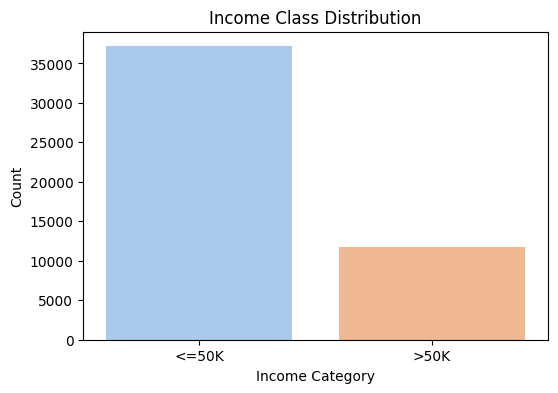

In [ ]:
# Check the column name
print("Columns:", df.columns.tolist())

target_col = "income"

# Show class imbalance
print("\nClass Distribution:\n")
print(df[target_col].value_counts())

print("\nPercentage Distribution:\n")
print(df[target_col].value_counts(normalize=True) * 100)

# Plot it
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df, palette="pastel")
plt.title("Income Class Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()


# **Data Preprocessing**

In [ ]:
# Handle missing values
df = df.replace('?', np.nan)

print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values with most frequent value
df = df.fillna(df.mode().iloc[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

Missing values before cleaning:
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Missing values after cleaning:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [ ]:
# Prepare data for training
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Default Decision Tree

print(" Default Decision Tree")


dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)

print("Default Tree Accuracy:", accuracy_score(y_test, y_pred_default))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=['<=50K', '>50K']))

#Tuned Decision Tree

print(" Tuned Decision Tree")

# Try different parameters
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    criterion='entropy',
    random_state=42
)

dt_tuned.fit(X_train, y_train)
y_pred_tuned = dt_tuned.predict(X_test)

print("Tuned Tree Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['<=50K', '>50K']))


Training set: 39073 samples
Test set: 9769 samples
 Default Decision Tree
Default Tree Accuracy: 0.8148223973794656

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      7431
        >50K       0.61      0.62      0.62      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.75      0.75      9769
weighted avg       0.82      0.81      0.82      9769

 Tuned Decision Tree
Tuned Tree Accuracy: 0.8556658818712253

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7431
        >50K       0.78      0.55      0.65      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.75      0.78      9769
weighted avg       0.85      0.86      0.85      9769



In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 30],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best cross-validation score:", grid_search.best_score_)

# Train with best parameters
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)

print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best cross-validation score: 0.8539655204882685
Best Model Accuracy: 0.8579179035725253


# **2. Visualize the tree either using plot tree from sklearn.tree or using graphviz for more detailed visualization**

Text(95.72222222222221, 0.5, 'Actual')

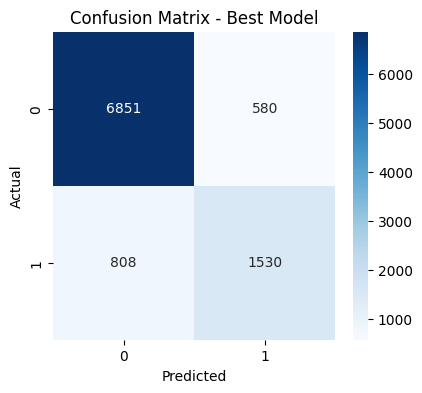

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for best model
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')


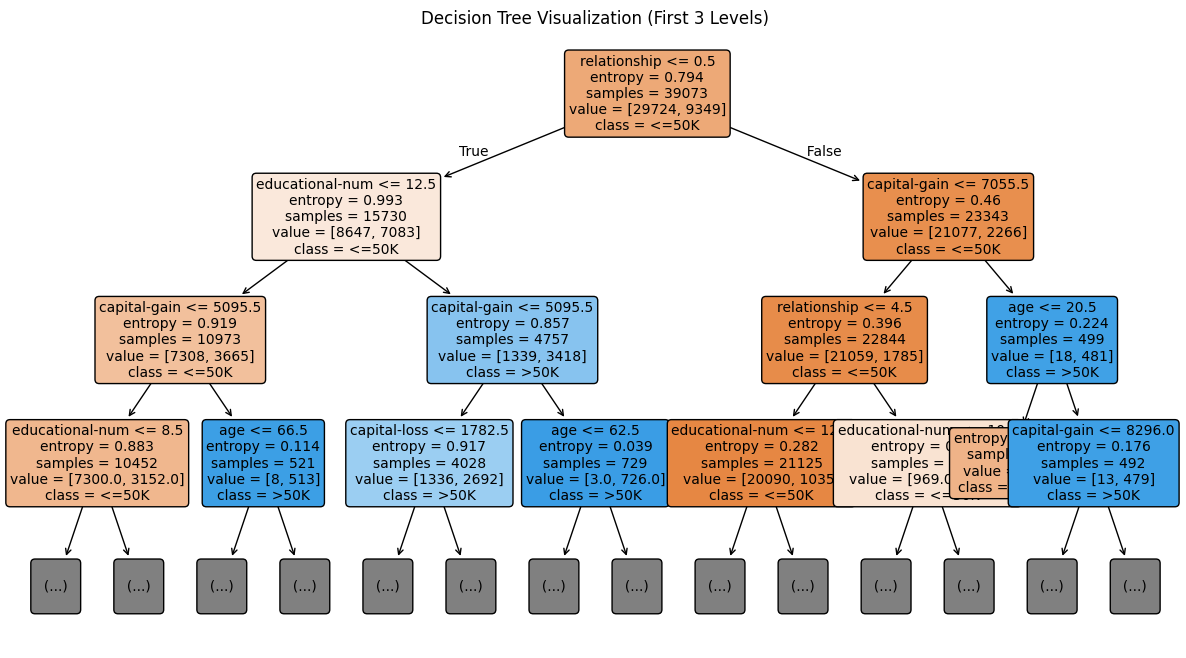

In [ ]:

plt.figure(figsize=(15, 8))
plot_tree(dt_tuned,
          feature_names=X.columns,
          class_names=['<=50K', '>50K'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()